## Imports and config ##

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, brier_score_loss

BASELINE_PATH = "outputs/processed/baseline.csv"
SYNTH_PATH = "outputs/synthetic"
SCALER_PATH = "outputs/processed/scaler.pkl"
CLIPS_PATH = "outputs/processed/clip_bounds.pkl"
RESULTS_PATH = "outputs/results/augmented_withheld"

# Label counts before augmentation
# BENIGN                        2273097
# DoS Hulk                       231073
# PortScan                       158930
# DDoS                           128027
# DoS GoldenEye                   10293
# FTP-Patator                      7938
# SSH-Patator                      5897
# Web Attack � Brute Force         1507
# Web Attack � XSS                  652

# withhheld to simulate novel attacks: DoS slowloris (5796), DoS Slowhttptest (5499), and Bot (1966)
# DoS slowloris                    5796
# DoS Slowhttptest                 5499
# Bot                              1966

# withheld to simulate rare attacks: Infiltration (36), WA: Sql Injection (21), Heartbleed (11) - they cannot reliably be used in synthetic generation
# Infiltration                       36
# Web Attack � Sql Injection         21
# Heartbleed                         11

WITHHELD_LABELS = [
    "DoS slowloris",
    "DoS Slowhttptest",
    "Bot",
    "Infiltration",
    "Web Attack � Sql Injection",
    "Heartbleed",
]

SYNTHETIC_PASSED = [
    "DoS Hulk",
    "DDoS",
    "DoS GoldenEye",
    "FTP-Patator",
    "SSH-Patator",
]

print(f"Withheld labels: {WITHHELD_LABELS}")
print(f"Synthetic labels: {SYNTHETIC_PASSED}")
print("Imports and Config completed")

Withheld labels: ['DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Infiltration', 'Web Attack � Sql Injection', 'Heartbleed']
Synthetic labels: ['DoS Hulk', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator']
Imports and Config completed


## Preprocessing ##

Because the scaler was fit on clipped & log-transformed features in the GAN setup, the same transformation must be matched before the scaler can be used, otherwise feature values will be out of range

In [2]:
baseline = pd.read_csv(BASELINE_PATH)

# Re-enforce float32 after .csv round-trip
float_cols = baseline.select_dtypes(include="float64").columns
baseline[float_cols] = baseline[float_cols].astype("float32")

X_raw = baseline.drop("Label", axis=1)
y_raw = baseline["Label"]
FEATURE_NAMES = list(X_raw.columns)

print(f"Baseline : {baseline.shape}")
print(f"Features : {FEATURE_NAMES}")
print(f"\nLabel counts:")
print(y_raw.value_counts())

# clip each feature to the saved scaler's bounds
clip_bounds = joblib.load(CLIPS_PATH)
X_proc = X_raw.copy()
for col in X_proc.columns:
    low, high = clip_bounds[col]
    X_proc[col] = X_proc[col].clip(lower=low, upper=high)

# log1p transform specifically for Flow Packets/s (applied due to extreme right skew in some labels)
X_proc["Flow Packets/s"] = np.log1p(X_proc["Flow Packets/s"])

# ready to scale
scaler = joblib.load(SCALER_PATH)
X_scaled = scaler.transform(X_proc).astype(np.float32)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_NAMES)

print("\nPreprocessing cell completed")
print(f"Scaled range: [{X_scaled.values.min():.3f}, {X_scaled.values.max():.3f}]")

Baseline : (2520798, 16)
Features : ['Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Packets/s', 'Fwd IAT Std', 'Fwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']

Label counts:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Prepr

## Train/Test split ##

Ready to split dataset.

In [3]:
# separate training from withheld
# mask convention: "signals that variable is not data, but a filter to select data"
trainable_mask = ~y_raw.isin(WITHHELD_LABELS)
withheld_mask = y_raw.isin(WITHHELD_LABELS)

X_trainable = X_scaled[trainable_mask].reset_index(drop=True)
y_trainable = y_raw[trainable_mask].reset_index(drop=True)

X_withheld = X_scaled[withheld_mask].reset_index(drop=True)
y_withheld = y_raw[withheld_mask].reset_index(drop=True)

# stratified split
X_train, X_test_known, y_train, y_test_known = train_test_split(
    X_trainable, y_trainable,
    test_size = 0.2,
    stratify = y_trainable,
    random_state = 77,
)

# append withheld labels to test split only
# the idea of withholding a label is that the training splits never sees the data, only the testing split has it
# this simulates "novel & rare" attack labels
X_test = pd.concat([X_test_known, X_withheld], ignore_index=True)
y_test = pd.concat([y_test_known, y_withheld], ignore_index=True)

print("\nTrain/test split cell completed")
print(f"Train size : {len(X_train):,}")
print(f"Test size: {len(X_test):,} (known labels: {len(X_test_known):,}, withheld labels: {len(X_withheld):,})")
print("\nTrain label counts:")
print(y_train.value_counts())
print(f"\nTest label counts:")
print(y_test.value_counts())


Train/test split cell completed
Train size : 2,006,535
Test size: 514,263 (known labels: 501,634, withheld labels: 12,629)

Train label counts:
Label
BENIGN                      1676045
DoS Hulk                     138277
DDoS                         102411
PortScan                      72555
DoS GoldenEye                  8229
FTP-Patator                    4745
SSH-Patator                    2575
Web Attack � Brute Force       1176
Web Attack � XSS                522
Name: count, dtype: int64

Test label counts:
Label
BENIGN                        419012
DoS Hulk                       34569
DDoS                           25603
PortScan                       18139
DoS slowloris                   5385
DoS Slowhttptest                5228
DoS GoldenEye                   2057
Bot                             1948
FTP-Patator                     1186
SSH-Patator                      644
Web Attack � Brute Force         294
Web Attack � XSS                 130
Infiltration                 

## Load Synthetic Data ##
Append synthetic data to baseline

In [4]:
# load synthetic CSVs for labels that passed fidelity evaluation
# append to training set only — test set remains real data exclusively
print("Loading synthetic data...")

synth_dfs = []
for label in SYNTHETIC_PASSED:
    safe_name = label.replace(" ", "_").replace("/", "_")
    path      = os.path.join(SYNTH_PATH, f"{safe_name}_synthetic.csv")
    df        = pd.read_csv(path)
    synth_dfs.append(df)
    print(f"  {label:<20} {len(df):>8,} synthetic rows loaded")

synthetic_all = pd.concat(synth_dfs, ignore_index=True)
print(f"\nTotal synthetic rows : {len(synthetic_all):,}")

# apply same preprocessing as Cell 2, must match scaler fitting conditions
X_synth_raw  = synthetic_all.drop("Label", axis=1)
y_synth      = synthetic_all["Label"].reset_index(drop=True)

# clip to saved bounds
X_synth_proc = X_synth_raw.copy()
for col in X_synth_proc.columns:
    low, high = clip_bounds[col]
    X_synth_proc[col] = X_synth_proc[col].clip(lower=low, upper=high)

# log1p on Flow Packets/s
X_synth_proc["Flow Packets/s"] = np.log1p(X_synth_proc["Flow Packets/s"])

# scale with saved scaler — transform only
X_synth_scaled = scaler.transform(X_synth_proc).astype(np.float32)
X_synth_scaled = pd.DataFrame(X_synth_scaled, columns=FEATURE_NAMES)

# append to training data only
X_train = pd.concat([X_train, X_synth_scaled], ignore_index=True)
y_train = pd.concat([y_train, y_synth],        ignore_index=True)

print(f"\nAugmented training set : {len(X_train):,} samples")
print(f"\nAugmented training label counts:")
print(y_train.value_counts())

Loading synthetic data...
  DoS Hulk               20,000 synthetic rows loaded
  DDoS                   20,000 synthetic rows loaded
  DoS GoldenEye          51,430 synthetic rows loaded
  FTP-Patator            29,655 synthetic rows loaded
  SSH-Patator            16,095 synthetic rows loaded

Total synthetic rows : 137,180

Augmented training set : 2,143,715 samples

Augmented training label counts:
Label
BENIGN                      1676045
DoS Hulk                     158277
DDoS                         122411
PortScan                      72555
DoS GoldenEye                 59659
FTP-Patator                   34400
SSH-Patator                   18670
Web Attack � Brute Force       1176
Web Attack � XSS                522
Name: count, dtype: int64


## Label Encoding ##
Necessary to do label encoding for XGBoost classifier, but also simplifies soft voting aggregated results later by having the same format for all models

In [5]:
# capture every label from y_raw
le = LabelEncoder()
le.fit(y_raw.unique())

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print("Label encoding cell completed")
print(f"Classes ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    print(f"{i:>2} : {cls}")

Label encoding cell completed
Classes (15):
 0 : BENIGN
 1 : Bot
 2 : DDoS
 3 : DoS GoldenEye
 4 : DoS Hulk
 5 : DoS Slowhttptest
 6 : DoS slowloris
 7 : FTP-Patator
 8 : Heartbleed
 9 : Infiltration
10 : PortScan
11 : SSH-Patator
12 : Web Attack � Brute Force
13 : Web Attack � Sql Injection
14 : Web Attack � XSS


## Model Initialization ##
Initialize models to be used. #if validation split becomes relevant, also tune parameters here#

In [6]:
# chosen models to represent "Collective Intelligence":
# LogisticRegression, MLP, XGBoost
# aggregated results through VotingClassifier with soft voting
lr_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=77,
    n_jobs=-1,
)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(256,128),
    max_iter=300,
    random_state=77,
    early_stopping=True,
    validation_fraction=0.1,
)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=77,
    n_jobs=-1,
)

# collective intelligence
ensemble = VotingClassifier(
    estimators=[("lr", lr_clf), ("mlp", mlp_clf), ("xgb", xgb_clf)],
    voting="soft",
)

print("Model initialization completed")

Model initialization completed


## Training ##


In [7]:
print("Starting training..")
print(f"Training samples: {len(X_train):,}")
print(f"Features: {len(FEATURE_NAMES):,}")

start_time = time.time()
ensemble.fit(X_train.values, y_train_enc)
elapsed = time.time() - start_time

print(f"Training completed, elapsed time: {elapsed:.1f}s")

Starting training..
Training samples: 2,143,715
Features: 15
Training completed, elapsed time: 1152.2s


## Evaluation ##
Evaluate metrics using sklearn's classification report, save to results

In [8]:
# need to decode integers back to label names
y_pred_enc = ensemble.predict(X_test.values)
y_pred_labels = le.inverse_transform(y_pred_enc)

# pretty print of results in classification report
print("=" * 70)
print("Classification Report — Augmented, withheld labels in test set")
print("=" * 70)
print(classification_report(
    y_test, y_pred_labels,
    zero_division = 0
))

# save report
report_dict = classification_report(
    y_test, y_pred_labels,
    output_dict   = True,
    zero_division = 0
)
pd.DataFrame(report_dict).transpose().to_csv(
    os.path.join(RESULTS_PATH, "classification_report.csv")
)
print(f"Report saved: {RESULTS_PATH}/classification_report.csv")

Classification Report — Augmented, withheld labels in test set
                            precision    recall  f1-score   support

                    BENIGN       0.97      1.00      0.99    419012
                       Bot       0.00      0.00      0.00      1948
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.55      0.99      0.71      2057
                  DoS Hulk       0.99      0.99      0.99     34569
          DoS Slowhttptest       0.00      0.00      0.00      5228
             DoS slowloris       0.00      0.00      0.00      5385
               FTP-Patator       1.00      0.99      1.00      1186
                Heartbleed       0.00      0.00      0.00        11
              Infiltration       0.00      0.00      0.00        36
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      0.97      0.98       644
  Web Attack � Brute Force       0.69      0.90     

## Calibration Plots ##
To answer whether predicted probabilities match actual outcomes. It will be a way to measure a difference between baseline and baseline + synthetic data, when classification report metrics are too good

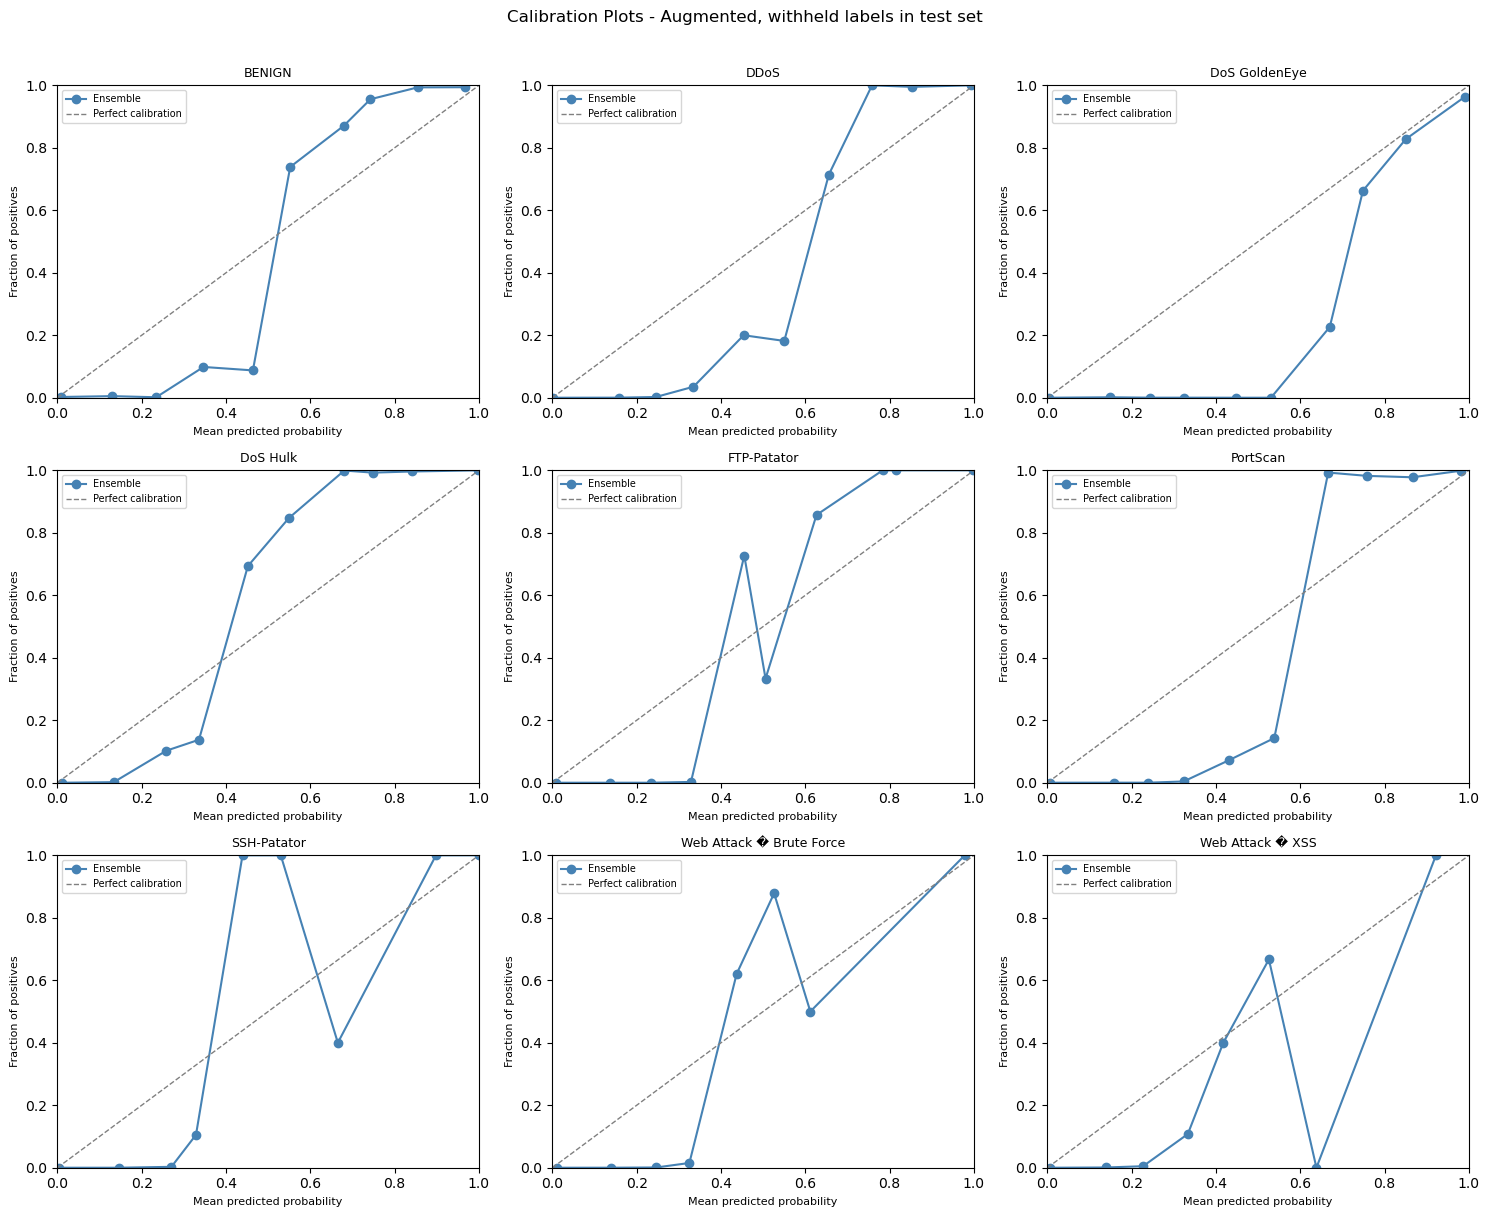

Calibration plots saved → outputs/results/augmented_withheld/calibration_plots.png


In [9]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# get predicted probabilities from ensemble
y_prob = ensemble.predict_proba(X_test.values)

# get class order from the ensemble itself
# ensemble.classes_ contains integer encoded classes it was trained on
# inverse transform back to label strings for readable plot titles
ensemble_classes = le.inverse_transform(ensemble.classes_)

# only plot known training labels
# withheld labels have no meaningful calibration — model never trained on them
labels_to_plot = [c for c in ensemble_classes if c not in WITHHELD_LABELS]

ncols = 3
nrows = int(np.ceil(len(labels_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, label in enumerate(labels_to_plot):
    ax = axes[i]

    # get index from ensemble's own class ordering
    class_idx = list(ensemble_classes).index(label)

    # binary: this class vs all others
    y_binary     = (y_test == label).astype(int).values
    y_prob_class = y_prob[:, class_idx]

    # compute calibration curve
    # n_bins controls granularity — 10 is standard
    prob_true, prob_pred = calibration_curve(
        y_binary, y_prob_class,
        n_bins   = 10,
        strategy = 'uniform'
    )

    # plot calibration curve
    ax.plot(prob_pred, prob_true,
            marker    = 'o',
            linewidth = 1.5,
            color     = 'steelblue',
            label     = 'Ensemble')

    # perfect calibration reference line
    ax.plot([0, 1], [0, 1],
            linestyle = '--',
            color     = 'gray',
            linewidth = 1.0,
            label     = 'Perfect calibration')

    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Mean predicted probability', fontsize=8)
    ax.set_ylabel('Fraction of positives', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# hide unused axes
for k in range(len(labels_to_plot), len(axes)):
    axes[k].set_visible(False)

fig.suptitle('Calibration Plots - Augmented, withheld labels in test set',
             fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'calibration_plots.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Calibration plots saved → {RESULTS_PATH}/calibration_plots.png")

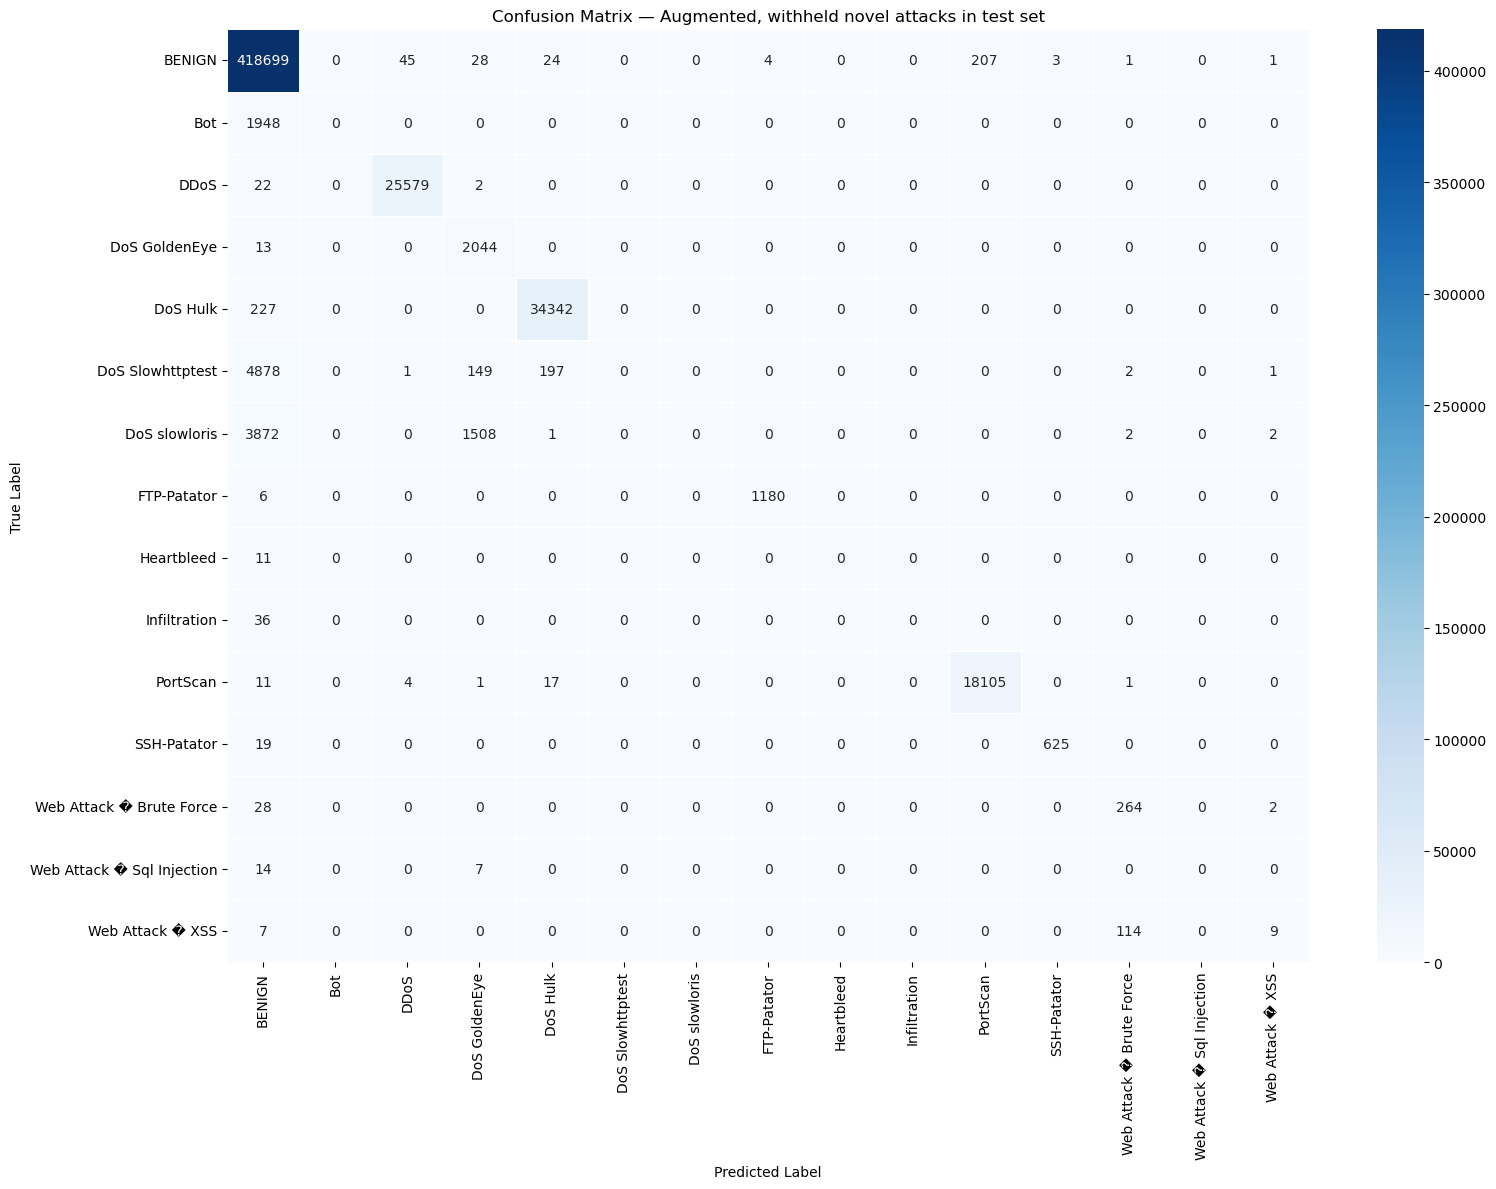

Confusion matrix saved: outputs/results/augmented_withheld/confusion_matrix.png


In [10]:
# additionally, plot a confusion matrix
labels_in_test = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_labels, labels=labels_in_test)
cm_df = pd.DataFrame(cm, index=labels_in_test, columns=labels_in_test)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    cm_df, ax=ax,
    cmap      = "Blues",
    fmt       = "d",
    annot     = True,
    linewidths= 0.5,
)
ax.set_title("Confusion Matrix — Augmented, withheld novel attacks in test set")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved: {RESULTS_PATH}/confusion_matrix.png")

## Special cell to breakdown withheld labels ##
Show specifically how the ensemble handled the withheld labels.

In [11]:
# same mask concept as in cell 3, applied only to the test set
withheld_mask_test = y_test.isin(WITHHELD_LABELS)
y_test_withheld = y_test[withheld_mask_test].reset_index(drop=True)
y_pred_withheld = pd.Series(y_pred_labels)[withheld_mask_test.values]

# classification report specifically on withheld labels
print(classification_report(
    y_test_withheld, y_pred_withheld,
    zero_division = 0
))

# loop through labels individually and show prediction % for each one.
# final line: what fraction of rare attack traffic was classified as something != benign
print("Withheld label prediction breakdown:")
for label in WITHHELD_LABELS:
    mask = y_test_withheld == label
    if mask.sum() == 0:
        continue
    preds = y_pred_withheld[mask.values].value_counts()
    total          = mask.sum()
    correct_attack = preds[preds.index != "BENIGN"].sum()
    print(f"  {label} (n={total:,})")
    for pred_class, count in preds.items():
        pct = count / total * 100
        print(f"    → {pred_class:<35} {count:>5}  ({pct:.1f}%)")
    print(f"    Non-BENIGN predictions: {correct_attack}/{total} ({correct_attack/total*100:.1f}%)\n")

withheld_report = classification_report(
    y_test_withheld, y_pred_withheld,
    zero_division = 0,
    output_dict   = True
)
pd.DataFrame(withheld_report).transpose().to_csv(
    os.path.join(RESULTS_PATH, "withheld_report.csv")
)
print(f"Withheld report saved: {RESULTS_PATH}/withheld_report.csv")

                            precision    recall  f1-score   support

                    BENIGN       0.00      0.00      0.00       0.0
                       Bot       0.00      0.00      0.00    1948.0
                      DDoS       0.00      0.00      0.00       0.0
             DoS GoldenEye       0.00      0.00      0.00       0.0
                  DoS Hulk       0.00      0.00      0.00       0.0
          DoS Slowhttptest       0.00      0.00      0.00    5228.0
             DoS slowloris       0.00      0.00      0.00    5385.0
                Heartbleed       0.00      0.00      0.00      11.0
              Infiltration       0.00      0.00      0.00      36.0
  Web Attack � Brute Force       0.00      0.00      0.00       0.0
Web Attack � Sql Injection       0.00      0.00      0.00      21.0
          Web Attack � XSS       0.00      0.00      0.00       0.0

                  accuracy                           0.00   12629.0
                 macro avg       0.00      0.0

## Low resource experiment ##
Metrics are too perfect, need to worsen the metrics to allow area for synthetic data to show improvement

In [ ]:
LOW_RESOURCE_FRACTION = 0.01

X_train_lr, _, y_train_lr, _ = train_test_split(
    X_train, y_train,
    train_size   = LOW_RESOURCE_FRACTION,
    stratify     = y_train,
    random_state = 77,
)

y_train_lr_enc = le.transform(y_train_lr)

print(f"Low resource training set : {len(X_train_lr):,} samples")
print(f"({LOW_RESOURCE_FRACTION:.0%} of augmented training set of {len(X_train):,})")
print(f"\nLabel counts:")
print(y_train_lr.value_counts())

# fresh ensemble
lr_lr = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=77, n_jobs=-1)
mlp_lr = MLPClassifier(
    hidden_layer_sizes=(256,128), max_iter=300, random_state=77,
    early_stopping=True, validation_fraction=0.1)
xgb_lr = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="mlogloss", random_state=77, n_jobs=-1)

ensemble_lr = VotingClassifier(
    estimators=[("lr", lr_lr), ("mlp", mlp_lr), ("xgb", xgb_lr)],
    voting="soft",
)

print("\nTraining low resource ensemble (real data only)...")
t0 = time.time()
ensemble_lr.fit(X_train_lr.values, y_train_lr_enc)
print(f"Training complete: {time.time() - t0:.1f}s")

y_pred_lr_enc    = ensemble_lr.predict(X_test.values)
y_pred_lr_labels = le.inverse_transform(y_pred_lr_enc)

print("=" * 70)
print(f"Low Resource Report: {LOW_RESOURCE_FRACTION:.0%} real data, WITH synthetic data")
print("=" * 70)
print(classification_report(
    y_test, y_pred_lr_labels,
    zero_division = 0,
    digits        = 4
))

pd.DataFrame(classification_report(
    y_test, y_pred_lr_labels,
    output_dict=True, zero_division=0
)).transpose().to_csv(
    os.path.join(RESULTS_PATH, "low_resource_report.csv")
)
print(f"Report saved: {RESULTS_PATH}/low_resource_report.csv")

Low resource training set : 21,437 samples
(1% of augmented training set of 2,143,715)

Label counts:
Label
BENIGN                      16760
DoS Hulk                     1583
DDoS                         1224
PortScan                      725
DoS GoldenEye                 597
FTP-Patator                   344
SSH-Patator                   187
Web Attack � Brute Force       12
Web Attack � XSS                5
Name: count, dtype: int64

Training low resource ensemble (real data only)...
Training complete: 10.1s
Low Resource Report: 1% real data, NO synthetic
                            precision    recall  f1-score   support

                    BENIGN     0.9697    0.9975    0.9834    419012
                       Bot     0.0000    0.0000    0.0000      1948
                      DDoS     0.9908    0.9980    0.9944     25603
             DoS GoldenEye     0.5279    0.9893    0.6884      2057
                  DoS Hulk     0.9978    0.9502    0.9735     34569
          DoS Slowhttptest

## ROC-AUC per class ##
Evaluate the ensemble, per class, "does the model generally separate positives from negatives well"

In [ ]:
# predict class probabilities for the test set and map label encoding back to original feature names
y_prob = ensemble.predict_proba(X_test.values)
ensemble_classes = le.inverse_transform(ensemble.classes_)

print("ROC-AUC per class:")
print(f"{'Label':<35} {'AUC':>8}")
print("-" * 45)
auc_results = {}
for i, label in enumerate(ensemble_classes):
    if label in WITHHELD_LABELS:
        continue
    y_binary = (y_test == label).astype(int).values
    if y_binary.sum() == 0:
        continue
    auc = roc_auc_score(y_binary, y_prob[:, i])
    auc_results[label] = auc
    print(f"{label:<33} {auc:.4f}")

pd.Series(auc_results, name="ROC-AUC").to_csv(
    os.path.join(RESULTS_PATH, "roc_auc.csv")
)
print(f"AUC saved: {RESULTS_PATH}/roc_auc.csv")

## Brier scores ##
To test if model assigns probabilities that match reality of the distribution

In [ ]:
print("Brier score loss per class (lower is better):")
print(f"{'Label':<35} {'Brier':>8}")
print("-" * 45)
brier_results = {}

for i, label in enumerate(ensemble_classes):
    if label in WITHHELD_LABELS:
        continue
    y_binary = (y_test == label).astype(int).values
    y_prob_class = y_prob[:, i]
    bscore = brier_score_loss(y_binary, y_prob_class)
    brier_results[label] = bscore
    print(f"{label:<33} {bscore:.6f}")

pd.Series(brier_results, name="Brier").to_csv(
    os.path.join(RESULTS_PATH, "brier_scores.csv")
)
print(f"Brier scores saved: {RESULTS_PATH}/brier_scores.csv")


## Multiple runs with varied seeds ##
Ensure results are solid across multiple runs

In [ ]:
SEEDS = [22, 333, 44, 555, 78, 888]
all_results = []

for seed in SEEDS:
    print(f"\nRun with seed {seed}...")
    
    lr_clf = LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=seed, n_jobs=-1)
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=(256,128), max_iter=300,
        random_state=seed, early_stopping=True,
        validation_fraction=0.1)
    xgb_clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=seed, n_jobs=-1)
    
    ens = VotingClassifier(
        estimators=[('lr', lr_clf), ('mlp', mlp_clf), ('xgb', xgb_clf)],
        voting='soft')
    
    t0 = time.time()
    ens.fit(X_train.values, y_train_enc)
    
    y_pred = le.inverse_transform(ens.predict(X_test.values))
    report = classification_report(
        y_test, y_pred,
        output_dict=True, zero_division=0)
    report['seed'] = seed
    all_results.append(report)
    print(f"  Seed {seed} complete — {time.time()-t0:.1f}s")

# summarise mean and std per class
known_labels = [l for l in le.classes_ if l not in WITHHELD_LABELS]
print(f"\n{'Label':<35} {'Mean Recall':>12} {'Std':>8}")
print('─' * 58)
summary_rows = []
for label in known_labels:
    recalls = [r[label]['recall'] 
               for r in all_results 
               if label in r]
    if not recalls:
        continue
    mean_r = np.mean(recalls)
    std_r  = np.std(recalls)
    print(f"  {label:<33} {mean_r:.4f}       ±{std_r:.4f}")
    summary_rows.append({
        'Label'       : label,
        'Mean Recall' : round(mean_r, 4),
        'Std Recall'  : round(std_r, 4),
    })

pd.DataFrame(summary_rows).to_csv(
    os.path.join(RESULTS_PATH, 'multi_seed_recall.csv'),
    index=False
)
print(f"\nSaved → {RESULTS_PATH}/multi_seed_recall.csv")